## Квантование строки пикселей

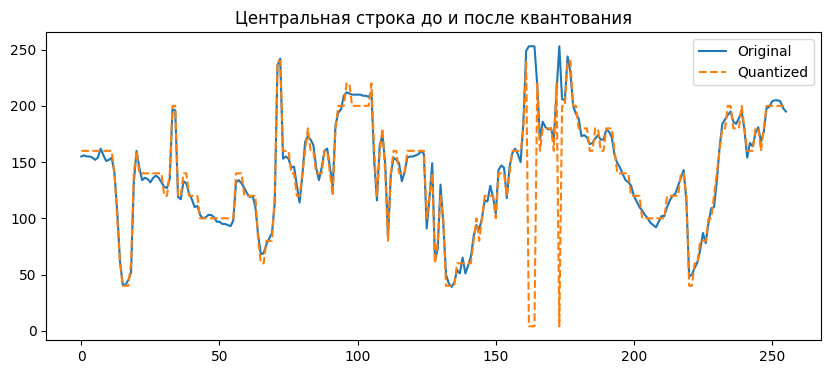

[160 160 160 160 160 160 160 160 160 160 160 160 140 100  60  40  40  40
  60 140 160 140 140 140 140 140 140 140 140 140 120 120 140 200 200 120
 120 140 140 120 120 120 120 100 100 100 100 100 100 100 100 100 100 100
 100 100 140 140 140 120 120 120 120 120  80  60  60  80  80  80 120 240
 240 160 160 160 140 140 120 120 140 160 180 160 160 140 140 140 160 160
 140 120 180 200 200 200 220 220 200 200 200 200 200 200 200 220 160 120
 160 180 140  80 140 160 160 140 140 140 160 160 160 160 160 160 160 100
 120 140  60  80 120 100  40  40  40  40  60  60  60  60  60  60  80 100
  80 100 120 120 120 120 100 140 140 140 120 140 160 160 160 160 180 240
   4   4   4 220 160 180 180 180 180 160 220   4 200 200 240 240 200 200
 180 180 180 180 160 160 180 180 160 160 180 180 180 160 140 140 140 140
 140 120 120 120 120 100 100 100 100 100 100 100 100 100 120 120 120 120
 120 140 140 120  40  40  60  60  80  80  80 100 100 120 140 160 180 180
 200 200 180 180 180 200 180 160 160 160 180 180 16

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "picture1.png"
img = Image.open(image_path)

img = img.resize((256, 256)) 

imgar = np.array(img)

crow = imgar[imgar.shape[0] // 2, :]  # строка посередине по высоте

quanrow = np.round(crow / 20) * 20
quanrow = quanrow.astype(np.uint8)

# Выводим результат
plt.figure(figsize=(10, 4))
plt.plot(crow, label='Original')
plt.plot(quanrow, label='Quantized', linestyle='--')
plt.legend()
plt.title('Центральная строка до и после квантования')
plt.show()

# Также можно сохранить, если нужно np.savetxt("quantized_row.txt", quantized_row, fmt='%d')

print(quanrow)

## Получение частот каждого символа и сортировка полученных частот

In [3]:
cha = dict()  # [число] = частота появления

for i in quanrow:  #тут пока считаем, сколько раз встретился каждый символ
    if (i in cha.keys()):
        cha[i] += 1
    else:
         cha[i] = 1

l = len(quanrow)
print(cha)

for i in cha.keys():  #кол-во символов определённых делим на кол-во всех символов
    cha[i] = cha[i] / l

chaso = dict(sorted(cha.items(), key=lambda item: item[1]))
print(chaso)

{160: 48, 140: 42, 100: 30, 60: 13, 40: 9, 120: 36, 200: 27, 80: 11, 240: 5, 180: 26, 220: 5, 4: 4}
{4: 0.015625, 240: 0.01953125, 220: 0.01953125, 40: 0.03515625, 80: 0.04296875, 60: 0.05078125, 180: 0.1015625, 200: 0.10546875, 100: 0.1171875, 120: 0.140625, 140: 0.1640625, 160: 0.1875}


## Построение дерева Хаффмана

In [39]:
import heapq
heap = [[freq, [sym, ""]] for sym, freq in chaso.items()]
heapq.heapify(heap)

#print(heap)

while len(heap) > 1:
    lo = heapq.heappop(heap)
    hi = heapq.heappop(heap)
    for pair in lo[1:]:
        pair[1] = "0" + pair[1]
    for pair in hi[1:]:
        pair[1] = '1' + pair[1]
    heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])


HC = dict()  #Хаффман Код
for i in heap[0][1:]:
    HC[i[0]] = i[1]

HC = dict(sorted(HC.items(), key=lambda item: item[0]))
print(HC)
for sym, code in HC.items():
    print(sym, " ", code)

{4: '010110', 40: '11100', 60: '0100', 80: '11101', 100: '100', 120: '101', 140: '110', 160: '00', 180: '1111', 200: '011', 220: '010111', 240: '01010'}
4   010110
40   11100
60   0100
80   11101
100   100
120   101
140   110
160   00
180   1111
200   011
220   010111
240   01010


In [ ]:
hufcode = sorted(heap[0][1:], key=lambda p: p[0])

for sym, code in hufcode:
    print(sym, " ", code)

In [43]:
a = [1, 2, 3]
b = [4, 5, 6]
c = [a + b] + b
print(c)
d = a + [9]
print(d)

[[1, 2, 3, 4, 5, 6], 4, 5, 6]
[1, 2, 3, 9]


## Кодировка числовой последовательности, полученной из пикселей фотографии, с помощью кодов Хаффмана

In [44]:
coded_quanrow = list()

for i in quanrow:
    coded_quanrow = coded_quanrow + [HC[i]]
print(quanrow)
print('')
print(coded_quanrow)

[160 160 160 160 160 160 160 160 160 160 160 160 140 100  60  40  40  40
  60 140 160 140 140 140 140 140 140 140 140 140 120 120 140 200 200 120
 120 140 140 120 120 120 120 100 100 100 100 100 100 100 100 100 100 100
 100 100 140 140 140 120 120 120 120 120  80  60  60  80  80  80 120 240
 240 160 160 160 140 140 120 120 140 160 180 160 160 140 140 140 160 160
 140 120 180 200 200 200 220 220 200 200 200 200 200 200 200 220 160 120
 160 180 140  80 140 160 160 140 140 140 160 160 160 160 160 160 160 100
 120 140  60  80 120 100  40  40  40  40  60  60  60  60  60  60  80 100
  80 100 120 120 120 120 100 140 140 140 120 140 160 160 160 160 180 240
   4   4   4 220 160 180 180 180 180 160 220   4 200 200 240 240 200 200
 180 180 180 180 160 160 180 180 160 160 180 180 180 160 140 140 140 140
 140 120 120 120 120 100 100 100 100 100 100 100 100 100 120 120 120 120
 120 140 140 120  40  40  60  60  80  80  80 100 100 120 140 160 180 180
 200 200 180 180 180 200 180 160 160 160 180 180 16